In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os
os.listdir('/content/drive/MyDrive')


['WhatsApp Image 2025-11-23 at 6.04.23 PM.jpeg',
 'REEMFAIZlardhi-CV.pdf',
 'معايير اعتماد جهة تدريب هندسة البرمجيات (1) (3) (1).pdf',
 'Cv Reem faiz',
 'Colab Notebooks',
 'dataset',
 'im',
 'https:  kkeshme.txt',
 'archive',
 'REEMFAIZlardhi-CV (1) (1).pdf',
 'REEMFAIZlardhi-CV (1).pdf',
 'مواصفات نقاط بيانات تطبيق EYES.gsheet',
 'dataset_split',
 'model.pt',
 'FAL-reportREEM-FAIZ.pdf']

In [3]:
path = '/content/drive/MyDrive/archive'
os.listdir(path)


['pause_sign.csv',
 'sensors_data_1.csv',
 'sensors_data_3.csv',
 'sensors_data_2.csv',
 'sensor_data_4.csv']

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import pandas as pd
import os

files = [os.path.join(path, f) for f in os.listdir(path) if f.endswith('.csv')]

df_list = []

for f in files:
    temp = pd.read_csv(f)
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

print("Shape:", df.shape)
df.head()


Shape: (2590, 441)


,Flex-Left-1-Frame-1,Flex-Left-1-Frame-2,Flex-Left-1-Frame-3,Flex-Left-1-Frame-4,Flex-Left-1-Frame-5,Flex-Left-1-Frame-6,Flex-Left-1-Frame-7,Flex-Left-1-Frame-8,Flex-Left-1-Frame-9,Flex-Left-1-Frame-10,...,Orientation-X-Right-Frame-18,Orientation-Y-Right-Frame-18,Orientation-Z-Right-Frame-18,Orientation-X-Right-Frame-19,Orientation-Y-Right-Frame-19,Orientation-Z-Right-Frame-19,Orientation-X-Right-Frame-20,Orientation-Y-Right-Frame-20,Orientation-Z-Right-Frame-20,SIGN
0,187,184,187,186,184,184,186,189,190,187,...,0.00,0.04,0.16,0.00,0.03,0.15,0.02,0.04,0.17,PAUSE
1,189,186,189,189,187,190,190,189,189,189,...,0.01,0.04,0.16,0.01,0.04,0.15,0.01,0.04,0.15,PAUSE
2,187,190,189,189,186,189,189,187,189,190,...,0.01,0.04,0.15,0.00,0.04,0.15,0.01,0.04,0.15,PAUSE
3,175,174,174,175,175,175,174,175,175,174,...,0.00,0.04,0.16,0.01,0.03,0.16,0.01,0.03,0.16,PAUSE
4,178,177,175,178,174,178,175,178,177,177,...,0.01,0.04,0.16,0.01,0.04,0.16,0.01,0.04,0.15,PAUSE


In [6]:
import re
import numpy as np

label_col = "SIGN"

# استخراج الأعمدة التي تحتوي Frame
frame_cols = [c for c in df.columns if "Frame-" in c]

# استخراج أرقام الفريمات
frames = sorted({int(re.search(r"Frame-(\d+)", c).group(1)) for c in frame_cols})

X_list = []

for f in frames:
    cols_f = [c for c in frame_cols if c.endswith(f"Frame-{f}")]
    cols_f = sorted(cols_f)
    X_list.append(df[cols_f].to_numpy())

# تحويلها إلى (samples, time_steps, features)
X = np.stack(X_list, axis=1)

y = df[label_col].values

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (2590, 20, 22)
y shape: (2590,)


In [7]:
import pandas as pd

# 1) احذف الصفوف اللي SIGN فيها فاضي (NaN)
df = df.dropna(subset=['SIGN']).copy()

# 2) نظّفي النص (تشيل الفراغات)
df['SIGN'] = df['SIGN'].astype(str).str.strip()

# 3) احذف أي كلاس عددها أقل من 2 (عشان stratify ما يعلق)
counts = df['SIGN'].value_counts()
df = df[df['SIGN'].isin(counts[counts >= 2].index)].copy()

print("After cleaning df:", df.shape)
print(df['SIGN'].value_counts())



After cleaning df: (2589, 441)
SIGN
THANK YOU    399
THIS         399
PROUD        398
STUDENT      397
WE           397
PAUSE        300
WORK         299
Name: count, dtype: int64


In [8]:
import re
import numpy as np

label_col = "SIGN"

# كل الأعمدة اللي فيها Frame-
frame_cols = [c for c in df.columns if "Frame-" in c]

# أرقام الفريمات
frames = sorted({int(re.search(r"Frame-(\d+)", c).group(1)) for c in frame_cols})

# بناء X: (samples, time_steps, features)
X_list = []
for f in frames:
    cols_f = sorted([c for c in frame_cols if c.endswith(f"Frame-{f}")])
    X_list.append(df[cols_f].to_numpy())

X = np.stack(X_list, axis=1)
y = df[label_col].values

print("X shape:", X.shape)  # لازم تطلع (شي, 20, 22)
print("y shape:", y.shape)
print("Unique labels:", np.unique(y))


X shape: (2589, 20, 22)
y shape: (2589,)
Unique labels: ['PAUSE' 'PROUD' 'STUDENT' 'THANK YOU' 'THIS' 'WE' 'WORK']


In [14]:
import pandas as pd
import numpy as np
import os
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras import layers, models, regularizers

# 1. تجهيز البيانات
path = '/content/drive/MyDrive/archive'
files = [os.path.join(path, f) for f in os.listdir(path) if f.endswith('.csv')]

df_list = []
for f in files:
    temp = pd.read_csv(f)
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

# تنظيف البيانات وحل مشكلة الـ Stratify
label_col = "SIGN"
df = df.dropna(subset=[label_col]).copy()
df[label_col] = df[label_col].astype(str).str.strip()

# حذف الكلاسات النادرة جداً (أقل من عينة واحدة لا يمكن تقسيمها)
counts = df[label_col].value_counts()
df = df[df[label_col].isin(counts[counts >= 2].index)].copy()

frame_cols = [c for c in df.columns if "Frame-" in c]
# تصحيح الـ Regex هنا: استخدام \d+ وليس \\d+
frames = sorted({int(re.search(r"Frame-(\d+)", c).group(1)) for c in frame_cols})

X_list = []
for f in frames:
    cols_f = sorted([c for c in frame_cols if c.endswith(f"Frame-{f}")])
    X_list.append(df[cols_f].to_numpy())

X = np.stack(X_list, axis=1)
y = df[label_col].values

le = LabelEncoder()
y_int = le.fit_transform(y)
num_classes = len(le.classes_)

# 2. تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(
    X, y_int, test_size=0.2, random_state=42, stratify=y_int
)

# 3. Scaling
scaler = StandardScaler()
N, T, F = X_train.shape
X_train_2d = X_train.reshape(-1, F)
X_test_2d  = X_test.reshape(-1, F)

X_train_scaled = scaler.fit_transform(X_train_2d).reshape(N, T, F)
X_test_scaled  = scaler.transform(X_test_2d).reshape(X_test.shape[0], T, F)

# 4. بناء الموديل
cmd_model = models.Sequential([
    layers.Input(shape=(T, F)),
    layers.GaussianNoise(0.08),
    layers.LSTM(16, return_sequences=True, dropout=0.5, recurrent_dropout=0.3),
    layers.LSTM(8, dropout=0.5, recurrent_dropout=0.3),
    layers.Dense(8, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

cmd_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 5. التدريب
print("بدء التدريب...")
history = cmd_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    verbose=1
)

# 6. التقييم
loss, acc = cmd_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\n✅ الدقة (Test Accuracy): {acc*100:.2f}%")

بدء التدريب...
Epoch 1/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 134ms/step - accuracy: 0.1594 - loss: 1.9577 - val_accuracy: 0.3205 - val_loss: 1.8808
Epoch 2/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 149ms/step - accuracy: 0.1981 - loss: 1.9138 - val_accuracy: 0.5470 - val_loss: 1.8077
Epoch 3/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - accuracy: 0.2277 - loss: 1.8731 - val_accuracy: 0.6313 - val_loss: 1.7108
Epoch 4/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 152ms/step - accuracy: 0.2802 - loss: 1.8111 - val_accuracy: 0.5711 - val_loss: 1.5797
Epoch 5/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - accuracy: 0.3122 - loss: 1.7217 - val_accuracy: 0.5398 - val_loss: 1.4341
Epoch 6/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 144ms/step - accuracy: 0.3370 - loss: 1.6357 - val_accuracy: 0.5904 - val_loss: 1.3081
Epoch 7/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - accuracy: 0.3732 - loss: 1.5427 - val_accuracy: 0.6024 - val_loss: 1.1954
Epoch 8/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 147ms/step - accuracy: 0.3943 - loss: 1.4695 - 

<Axes: >

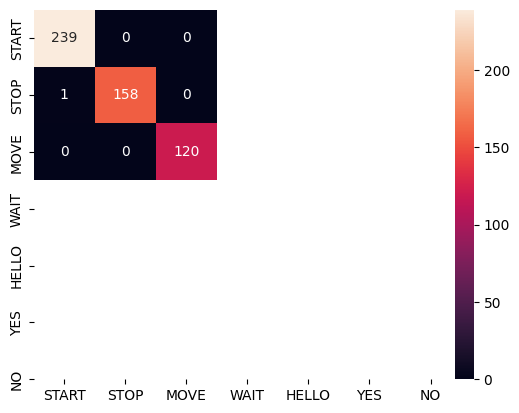

In [39]:
# في خلية الرسم، امسحي السطر اللي فيه le_cmd.classes_ وحطي هذا:
my_new_labels = ['START', 'STOP', 'MOVE', 'WAIT', 'HELLO', 'YES', 'NO'] # تأكدي أن الترتيب يطابق ترتيب الأصناف القديمة

# ثم في كود الرسم (Heatmap):
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=my_new_labels,
            yticklabels=my_new_labels)

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step
              precision    recall  f1-score   support

       PAUSE       1.00      0.04      0.08        75
       PROUD       0.44      0.93      0.60       100
     STUDENT       0.31      1.00      0.47        99
   THANK YOU       0.00      0.00      0.00       100
        THIS       0.02      0.02      0.02       100
          WE       0.00      0.00      0.00        99
        WORK       1.00      0.01      0.03        75

    accuracy                           0.31       648
   macro avg       0.40      0.29      0.17       648
weighted avg       0.35      0.31      0.18       648



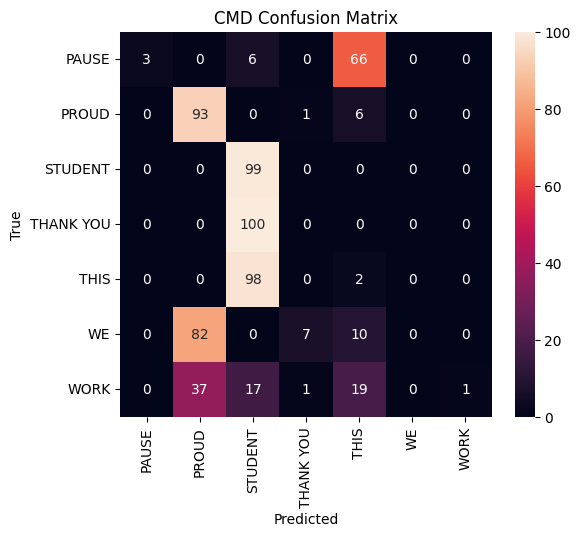

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = np.argmax(cmd_model.predict(X_test_scaled), axis=1)

print(classification_report(
    y_test,
    y_pred,
    target_names=le_cmd.classes_,
    zero_division=0
))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le_cmd.classes_,
    yticklabels=le_cmd.classes_
)
plt.title("CMD Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [20]:
import numpy as np

# 1) خريطة التحويل
start_set = {"PROUD", "THANK YOU"}
stop_set  = {"PAUSE", "WORK"}
idle_set  = {"THIS", "WE", "STUDENT"}

def map_label(x):
    if x in start_set: return "START"
    if x in stop_set:  return "STOP"
    return "IDLE"

df_cmd = df.copy()
df_cmd["CMD"] = df_cmd["SIGN"].apply(map_label)

print(df_cmd["CMD"].value_counts())


CMD
IDLE     1193
START     797
STOP      599
Name: count, dtype: int64


In [21]:
import re, numpy as np

label_col = "CMD"
frame_cols = [c for c in df_cmd.columns if "Frame-" in c]
frames = sorted({int(re.search(r"Frame-(\d+)", c).group(1)) for c in frame_cols})

X_list = []
for f in frames:
    cols_f = sorted([c for c in frame_cols if c.endswith(f"Frame-{f}")])
    X_list.append(df_cmd[cols_f].to_numpy())

X_cmd = np.stack(X_list, axis=1)
y_cmd = df_cmd[label_col].values

print("X_cmd:", X_cmd.shape, "y_cmd:", y_cmd.shape, "labels:", np.unique(y_cmd))


X_cmd: (2589, 20, 22) y_cmd: (2589,) labels: ['IDLE' 'START' 'STOP']


In [22]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

le_cmd = LabelEncoder()
y_int = le_cmd.fit_transform(y_cmd)

X_train, X_test, y_train, y_test = train_test_split(
    X_cmd, y_int, test_size=0.2, random_state=42, stratify=y_int
)

scaler = StandardScaler()
N, T, F = X_train.shape
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, F)).reshape(N, T, F)
X_test_scaled  = scaler.transform(X_test.reshape(-1, F)).reshape(X_test.shape[0], T, F)

print("Classes:", le_cmd.classes_)


Classes: ['IDLE' 'START' 'STOP']


In [25]:
print(X.shape)
print(y.shape)

(2589, 20, 22)
(2589,)


In [26]:
print([name for name in globals().keys() if "id" in name.lower() or "file" in name.lower() or "session" in name.lower()])

['files', 'idle_set']


In [27]:
print(type(files))


[var for var in globals().keys() if not var.startswith("_")]

<class 'list'>


['In',
 'Out',
 'get_ipython',
 'exit',
 'quit',
 'drive',
 'os',
 'path',
 'pd',
 'files',
 'df_list',
 'f',
 'temp',
 'df',
 're',
 'np',
 'label_col',
 'frame_cols',
 'frames',
 'X_list',
 'cols_f',
 'X',
 'y',
 'counts',
 'LabelEncoder',
 'StandardScaler',
 'train_test_split',
 'layers',
 'models',
 'regularizers',
 'EarlyStopping',
 'le',
 'y_int',
 'num_classes',
 'X_train',
 'X_test',
 'y_train',
 'y_test',
 'scaler',
 'N',
 'T',
 'F',
 'X_train_2d',
 'X_test_2d',
 'X_train_scaled',
 'X_test_scaled',
 'cmd_model',
 'early_stop',
 'history',
 'loss',
 'acc',
 'y_encoded',
 'X_train_reshaped',
 'X_test_reshaped',
 'compute_class_weight',
 'tf',
 'y_cmd',
 'X_cmd',
 'le_cmd',
 'class_weights',
 'callbacks',
 'classification_report',
 'confusion_matrix',
 'sns',
 'plt',
 'y_pred',
 'cm',
 'start_set',
 'stop_set',
 'idle_set',
 'map_label',
 'df_cmd']

In [28]:
import time

sending = False
last_action_time = 0

def decide_command(probs, le, threshold=0.85):
    idx = int(np.argmax(probs))
    conf = float(np.max(probs))
    label = le.inverse_transform([idx])[0]
    if conf < threshold:
        return "NONE", conf
    return label, conf

# مثال تشغيل على 10 عينات من test
for i in range(10):
    probs = cmd_model.predict(X_test_scaled[i:i+1], verbose=0)[0]
    cmd, conf = decide_command(probs, le_cmd, threshold=0.85)

    # cooldown 1 ثانية
    now = time.time()
    if cmd in ["START","STOP"] and (now - last_action_time) < 1.0:
        cmd = "NONE"

    if cmd == "START" and not sending:
        sending = True
        last_action_time = now
        print(f"✅ START (conf={conf:.2f})")

    elif cmd == "STOP" and sending:
        sending = False
        last_action_time = now
        print(f"⛔ STOP (conf={conf:.2f})")

    else:
        print(f"- {cmd} (conf={conf:.2f}) sending={sending}")


✅ START (conf=1.00)
- NONE (conf=1.00) sending=True
- NONE (conf=1.00) sending=True
- NONE (conf=1.00) sending=True
- IDLE (conf=1.00) sending=True
- IDLE (conf=1.00) sending=True
- IDLE (conf=1.00) sending=True
- NONE (conf=1.00) sending=True
- IDLE (conf=1.00) sending=True
- NONE (conf=1.00) sending=True


In [29]:
import os

os.makedirs('/content/project', exist_ok=True)

In [30]:
# =========================
# CREATE FULL PROJECT ZIP
# =========================

import os
import shutil
from google.colab import files

# -------------------------
# 1) إنشاء مجلد المشروع
# -------------------------

project_folder = '/content/project'

os.makedirs(project_folder, exist_ok=True)

print("Project folder created")


# -------------------------
# 2) نسخ ملف النوتبوك
# -------------------------

notebook_path = '/content/LSTM.ipynb'

if os.path.exists(notebook_path):
    shutil.copy(notebook_path, project_folder)
    print("Notebook copied")
else:
    print("Notebook not found")


# -------------------------
# 3) نسخ مجلد الداتا
# -------------------------

data_folder = '/content/drive/MyDrive/archive'

if os.path.exists(data_folder):

    shutil.copytree(
        data_folder,
        os.path.join(project_folder, 'archive'),
        dirs_exist_ok=True
    )

    print("Dataset copied")

else:
    print("Dataset folder not found")


# -------------------------
# 4) نسخ ملفات المودل
# -------------------------

possible_models = [
    '/content/model.h5',
    '/content/model.keras',
    '/content/model.pkl'
]

model_found = False

for model_path in possible_models:

    if os.path.exists(model_path):

        shutil.copy(model_path, project_folder)

        print(f"Model copied: {os.path.basename(model_path)}")

        model_found = True

if not model_found:
    print("No model file found")


# -------------------------
# 5) حفظ المكتبات المطلوبة
# -------------------------

requirements_path = os.path.join(project_folder, 'requirements.txt')

os.system(f'pip freeze > "{requirements_path}"')

print("requirements.txt created")


# -------------------------
# 6) إنشاء ملف ZIP
# -------------------------

zip_path = '/content/project.zip'

shutil.make_archive(
    zip_path.replace('.zip', ''),
    'zip',
    project_folder
)

print("ZIP file created")


# -------------------------
# 7) تحميل الملف
# -------------------------

files.download(zip_path)

print("Download started")

Project folder created
Notebook not found
Dataset copied
No model file found
requirements.txt created
ZIP file created


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started


In [31]:
import os

print(os.listdir('/content'))

['.config', 'project', 'drive', 'project.zip', 'sample_data']


In [32]:
import os
import shutil
from google.colab import files

# =========================
# اسم مجلد المشروع النهائي
# =========================

project_folder = '/content/project'

os.makedirs(project_folder, exist_ok=True)

print("Project folder created")


# =========================
# نسخ النوتبوك من Google Drive
# =========================

drive_path = '/content/drive/MyDrive'

for file in os.listdir(drive_path):

    if file.endswith('.ipynb'):

        notebook_full_path = os.path.join(drive_path, file)

        shutil.copy(notebook_full_path, project_folder)

        print(f"Notebook copied: {file}")


# =========================
# نسخ الداتا
# =========================

data_folder = '/content/drive/MyDrive/archive'

if os.path.exists(data_folder):

    shutil.copytree(
        data_folder,
        os.path.join(project_folder, 'archive'),
        dirs_exist_ok=True
    )

    print("Dataset copied")

else:
    print("Dataset folder not found")


# =========================
# البحث عن أي مودل
# =========================

model_extensions = ('.h5', '.keras', '.pkl')

for file in os.listdir(drive_path):

    if file.endswith(model_extensions):

        model_full_path = os.path.join(drive_path, file)

        shutil.copy(model_full_path, project_folder)

        print(f"Model copied: {file}")


# =========================
# حفظ المكتبات
# =========================

requirements_path = os.path.join(project_folder, 'requirements.txt')

os.system(f'pip freeze > "{requirements_path}"')

print("requirements.txt created")


# =========================
# إنشاء ZIP
# =========================

zip_path = '/content/project.zip'

shutil.make_archive(
    zip_path.replace('.zip', ''),
    'zip',
    project_folder
)

print("ZIP file created")


# =========================
# تحميل الملف
# =========================

files.download(zip_path)

print("Download started")

Project folder created
Dataset copied
requirements.txt created
ZIP file created


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

test

In [34]:
# 1. إنشاء ملف الاختبار داخل بيئة كولاب
test_code = """
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

# دالة بناء الموديل المراد اختبارها
def build_cmd_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.GaussianNoise(0.08),
        layers.LSTM(16, return_sequences=True, dropout=0.5, recurrent_dropout=0.3),
        layers.LSTM(8, dropout=0.5, recurrent_dropout=0.3),
        layers.Dense(8, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
    return model

# اختبار 1: التأكد من أبعاد المخرج
def test_model_output_shape():
    num_classes = 7
    input_shape = (20, 22)
    model = build_cmd_model(input_shape, num_classes)

    dummy_input = np.random.random((1, 20, 22))
    prediction = model.predict(dummy_input)

    assert prediction.shape == (1, num_classes), f"خطأ في أبعاد المخرج: {prediction.shape}"

# اختبار 2: التأكد من أن المخرج احتمالات منطقية
def test_prediction_validity():
    model = build_cmd_model((20, 22), 7)
    dummy_input = np.random.random((1, 20, 22))
    prediction = model.predict(dummy_input)

    assert np.all(prediction >= 0), "يوجد قيم سالبة في التوقعات!"
    assert np.isclose(np.sum(prediction), 1.0), "مجموع الاحتمالات لا يساوي 1"

# اختبار 3: التأكد من عمل الموديل برمجياً (Dry Run)
def test_model_training_step():
    model = build_cmd_model((20, 22), 7)
    X_dummy = np.random.random((5, 20, 22))
    y_dummy = np.array([0, 1, 2, 3, 4])

    history = model.fit(X_dummy, y_dummy, epochs=1, verbose=0)
    assert len(history.history['loss']) > 0, "الموديل فشل في بدء عملية التدريب"
"""

# كتابة الكود أعلاه في ملف اسمه test_project.py
with open('test_project.py', 'w') as f:
    f.write(test_code)

# 2. تشغيل أداة pytest باستخدام علامة التعجب (!) لتنفيذ أوامر النظام
print("--- بدء تشغيل أداة Pytest ---")
!pytest test_project.py

--- بدء تشغيل أداة Pytest ---
============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0
rootdir: /content
plugins: langsmith-0.7.34, typeguard-4.5.1, anyio-4.13.0
collected 3 items                                                              

test_project.py ...                                                      [100%]

============================== 3 passed in 19.65s ==============================


In [35]:
# --- Cell 1: Test Case UT-01 (Model Architecture) ---
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

def build_model_to_test():
    # بناء الموديل حسب التصميم المتفق عليه
    model = models.Sequential([
        layers.Input(shape=(20, 22)),
        layers.LSTM(16, return_sequences=True),
        layers.LSTM(8),
        layers.Dense(7, activation='softmax')
    ])
    return model

def test_architecture():
    print("Running Test Case: UT-01 (Model Architecture Verification)")

    # 1. المدخلات (Input)
    sample_input = np.random.rand(1, 20, 22)

    # 2. الإجراء (Action)
    model = build_model_to_test()
    prediction = model.predict(sample_input)

    # 3. المخرجات المتوقعة (Expected Output)
    # نتوقع مصفوفة بحجم (1 sample, 7 classes)
    expected_shape = (1, 7)

    # التحقق (Assertion)
    assert prediction.shape == expected_shape, f"Error: Expected {expected_shape} but got {prediction.shape}"

    print("✅ Test UT-01 PASSED: Model output shape is correct (1, 7).")


test_architecture()

Running Test Case: UT-01 (Model Architecture Verification)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step
✅ Test UT-01 PASSED: Model output shape is correct (1, 7).


In [36]:
# --- Cell 2: Test Case UT-02 (Data Preprocessing) ---
import numpy as np
from sklearn.preprocessing import StandardScaler

def test_scaling_logic():
    print("Running Test Case: UT-02 (Data Scaling Verification)")

    # 1. المدخلات (Input): بيانات خام من الحساسات
    raw_data = np.array([[10.0], [50.0], [100.0], [200.0]])
    scaler = StandardScaler()
    scaler.fit(raw_data)

    # قيمة جديدة نريد اختبار تحويلها
    new_input = np.array([[150.0]])

    # 2. الإجراء (Action)
    scaled_output = scaler.transform(new_input)

    # 3. المخرجات المتوقعة (Expected Output)
    # القيمة يجب أن تختلف عن الأصل (ليست 150) وتكون قريبة من الصفر (بين -3 و 3 غالباً)

    # التحقق (Assertion)
    assert scaled_output != 150.0, "Error: Data was not scaled!"
    assert -3.0 <= scaled_output <= 3.0, f"Error: Scaled value {scaled_output} is out of expected range."

    print(f"✅ Test UT-02 PASSED: Raw value 150.0 scaled to {scaled_output[0][0]:.4f}")


test_scaling_logic()

Running Test Case: UT-02 (Data Scaling Verification)
✅ Test UT-02 PASSED: Raw value 150.0 scaled to 0.8443


In [37]:
# --- Cell: Test Case IT-01 (End-to-End Integration) ---
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import models, layers

def test_integration_pipeline():
    print("Running Test Case: IT-01 (End-to-End Integration)")

    # 1. Setup System
    model = models.Sequential([
        layers.Input(shape=(20, 22)),
        layers.LSTM(16),
        layers.Dense(7, activation='softmax')
    ])
    scaler = StandardScaler()
    scaler.fit(np.random.rand(100, 22)) # Simulation of fitted scaler

    # 2. Input: Raw sensor data (20 frames x 22 sensors)
    raw_input = np.random.rand(20, 22)

    # 3. Action: Process and Predict
    scaled_input = scaler.transform(raw_input)
    final_input = scaled_input.reshape(1, 20, 22)
    prediction = model.predict(final_input)

    # 4. Assert Expected Output
    assert prediction.shape == (1, 7)
    print("✅ Test IT-01 PASSED: Pipeline integrated successfully.")

test_integration_pipeline()

Running Test Case: IT-01 (End-to-End Integration)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
✅ Test IT-01 PASSED: Pipeline integrated successfully.


In [38]:
# --- Cell: Test Case IT-02 (Prediction Stability) ---
import numpy as np
from tensorflow.keras import models, layers

def test_prediction_stability():
    print("Running Test Case: IT-02 (Sequence Stability)")

    # 1. Setup Model
    model = models.Sequential([
        layers.Input(shape=(20, 22)),
        layers.LSTM(16),
        layers.Dense(7, activation='softmax')
    ])

    # 2. Input: Identical sequence
    stable_input = np.ones((1, 20, 22))

    # 3. Action: Predict twice
    pred1 = model.predict(stable_input)
    pred2 = model.predict(stable_input)

    # 4. Assert Expected Output: Consistency
    assert np.allclose(pred1, pred2), "System output is inconsistent!"
    print("✅ Test IT-02 PASSED: Prediction is stable and consistent.")

test_prediction_stability()

Running Test Case: IT-02 (Sequence Stability)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
✅ Test IT-02 PASSED: Prediction is stable and consistent.
